# Statistics for any asteroid:
The first two slides don't have to be rerun to get the result for a different asteroid.

In [1]:
import json
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import random

In [2]:
with open("observability.json", "r") as f:
    data = json.load(f)

## For any asteroid.

The following blocks can be rerun for different asteroids. 

In [45]:
i = random.randint(1, 6000)
i = str(i)

mpcnum = i
print(len(data[mpcnum]),"entries found")
print(i)
data[mpcnum]

5736 entries found
5855


[[2447589.559027778, 'dnb06566', 54.078962383183146, 33.230491889541874],
 [2447587.5576388887, 'dnb06558', 53.339769978366306, 33.14940507157793],
 [2447554.5847222223, 'dnb06534', 43.50947517646317, 32.18596268386601],
 [2447554.53125, 'dnb06532', 43.49793081749816, 32.18530294167845],
 [2447538.519444444, 'dnb06512', 40.87256205770745, 32.171273058723095],
 [2447529.5847222223, 'dnb06502', 40.23344481605245, 32.33033304210865],
 [2447526.5708333333, 'dnb06496', 40.16927740843324, 32.40891188339518],
 [2447505.659722222, 'dnb06473', 42.00649459688855, 33.14476734237268],
 [2447499.6322916667, 'dnb06451', 43.276740869847266, 33.339650879963045],
 [2447497.6086805556, 'dnb06443', 43.76912169173668, 33.392953154862596],
 [2447476.773611111, 'dnb06418', 50.08549937071925, 33.281390681251],
 [2447475.740277778, 'dnb06416', 50.42299246406365, 33.23558088498164],
 [2447469.7131944443, 'dnb06400', 52.347410683651255, 32.88320199318762],
 [2447448.60625, 'dnb06379', 57.477947646717105, 30.648

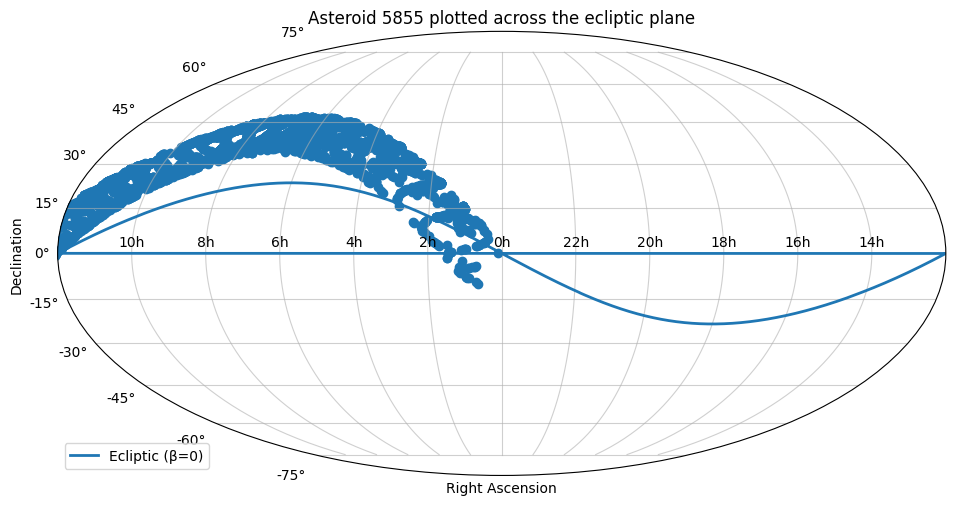

In [46]:
data_array = data[mpcnum]
data_array = np.array(data[mpcnum]).astype(object)
ras= data_array[:,2].astype(float)
decs = data_array[:,3].astype(float)

# --- Ecliptic (β=0) -> Equatorial (RA, Dec) using mean obliquity ---
eps_deg = 23.43928  # obliquity of the ecliptic (deg), good enough for plotting
eps = np.deg2rad(eps_deg)

lam = np.linspace(0, 2*np.pi, 4000)  # ecliptic longitude λ
# For β=0:
dec = np.arcsin(np.sin(eps) * np.sin(lam))
ra  = np.arctan2(np.sin(lam) * np.cos(eps), np.cos(lam))  # range [-pi, pi]

# Convert RA so it increases to the left (astronomy convention)
x = -ra  # flip so RA increases to the left

# --- Plot ---
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

ax.plot(x, dec, lw=2, label="Ecliptic (β=0)")

xticks = np.deg2rad(np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]))
# Because we flipped x = -ra, these correspond to RA labels reversed:
# Standard choice: show 10h, 8h, ..., 14h etc. A common, clear set:
ax.set_xticks(xticks)
ax.set_xticklabels(["10h","8h","6h","4h","2h","0h","22h","20h","18h","16h","14h"])

ax.grid(True, alpha=0.6)
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.legend(loc="lower left")
plt.tight_layout()
plt.scatter(- np.deg2rad(ras), np.deg2rad(decs))
plt.title("Asteroid {0} plotted across the ecliptic plane".format(i))
plt.savefig("Ecliptic_plane_image{0}.jpg".format(i), dpi=600)
plt.show()



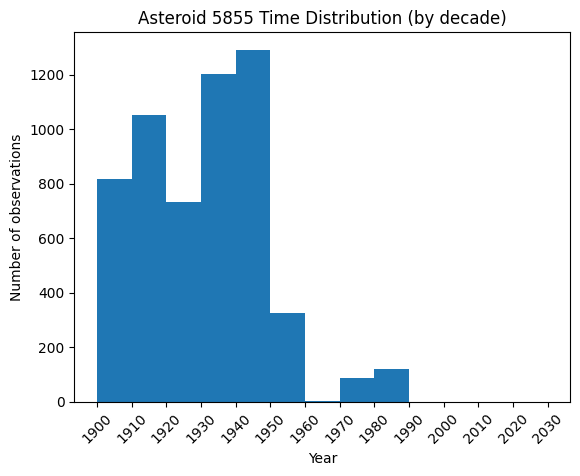

In [47]:
import json
import matplotlib.pyplot as plt
import numpy as np
# Extract Julian Dates

julian_dates = [row[0] for row in data[mpcnum]]
julian_dates = [float(row[0]) for row in data[mpcnum]]

# Convert JD to year
years = [1 + (jd - 1721425.5) / 365.25 for jd in julian_dates] 
years = [y for y in years if 1900 <= y <= 2030]

# Decade bins
bins = np.arange(1900, 2040, 10) # Approximate timespan the photographic plates cover

# Plot histogram
plt.hist(years, bins=bins)
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Asteroid {0} Time Distribution (by decade)".format(i))
plt.xticks(bins, rotation=45)
plt.savefig("Time_distribution_Bertha {0}.png".format(i), dpi=600)
plt.show()

In [ ]:
for i in range(1, 20):
    #j = random.randint(1, 6000)
    j = 1608
    mpcnum = j
    data[mpcnum]
    data_array = data[mpcnum]
    data_array = np.array(data[mpcnum]).astype(object)
    ras= data_array[:,2].astype(float)
    decs = data_array[:,3].astype(float)

# --- Ecliptic (β=0) -> Equatorial (RA, Dec) using mean obliquity ---
    ps_deg = 23.43928  # of the ecliptic (deg), good enough for plotting
    ps = np.deg2rad(eps_deg)

    lam = np.linspace(0, 2*np.pi, 4000)  # ecliptic longitude λ
# For β=0:
    dec = np.arcsin(np.sin(eps) * np.sin(lam))
    ra  = np.arctan2(np.sin(lam) * np.cos(eps), np.cos(lam))  # range [-pi, pi]

# Convert RA so it increases to the left (astronomy convention)
    x = -ra  # flip so RA increases to the left

# --- Plot ---
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection="mollweide")

    ax.plot(x, dec, lw=2, label="Ecliptic (β=0)")

    xticks = np.deg2rad(np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]))
# Because we flipped x = -ra, these correspond to RA labels reversed:
# Standard choice: show 10h, 8h, ..., 14h etc. A common, clear set:
    ax.set_xticks(xticks)
    ax.set_xticklabels(["10h","8h","6h","4h","2h","0h","22h","20h","18h","16h","14h"])

    ax.grid(True, alpha=0.6)
    ax.set_xlabel("Right Ascension")
    ax.set_ylabel("Declination")
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.scatter(- np.deg2rad(ras), np.deg2rad(decs))
    plt.title("Bertha plotted across the ecliptic plane")
    plt.savefig("Ecliptic_plane_image.jpg", dpi=600)
    plt.show()
print(ra, dec)

KeyError: 1608